In [18]:
import geopandas as gpd
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from sklearn.preprocessing import StandardScaler
from libpysal.weights import Queen

BASE = "/home/jovyan/work/children15mc"
PROC = f"{BASE}/data/processed"
FIG = f"{BASE}/outputs/figures"

df = gpd.read_file(f"{PROC}/accessibility.gpkg")

w_check = Queen.from_dataframe(df, use_index=False)
df = df.drop(index=w_check.islands).reset_index(drop=True)

df["area_km2"] = df.geometry.area / 1e6
df["child_density"] = df["child_pop"] / df["area_km2"]
df["c15mc_log"] = np.log(df["c15mc_score"] + 1)
scaler = StandardScaler()
df[["idaci_z","child_density_z"]] = scaler.fit_transform(df[["idaci_score","child_density"]])

y = df["c15mc_log"].values.reshape(-1, 1)
X = df[["idaci_z", "child_density_z"]].values
coords = list(zip(df["cent_x"], df["cent_y"]))

from libpysal.weights import Queen
w_check = Queen.from_dataframe(df, use_index=False)
islands = w_check.islands
df = df.drop(index=islands).reset_index(drop=True)
print(f"y/X/coords are {len(df)} rows")  

/opt/conda/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 1550, 4627.
  W.__init__(self, neighbors, ids=ids, **kw)


y/X/coords are 4657 rows


In [19]:
# Automatically select optimal bandwidth
sel = Sel_BW(coords, y, X)
bw = sel.search()
print(f"optimal bandwidth: {bw}")

optimal bandwidth: 47.0


In [21]:
# Run GWR using the selected bandwidth
gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()

print("GWR results")
print(f"GWR R²    =   {gwr_results.R2:.3f}")
print(f"OLS R²    =   0.166") 
print(f"AICc      =   {gwr_results.aicc:.1f}")

df["gwr_idaci_coef"] = gwr_results.params[:, 1]   
df["gwr_localR2"] = gwr_results.localR2

GWR results
GWR R²    =   0.699
OLS R²    =   0.166
AICc      =   6107.2


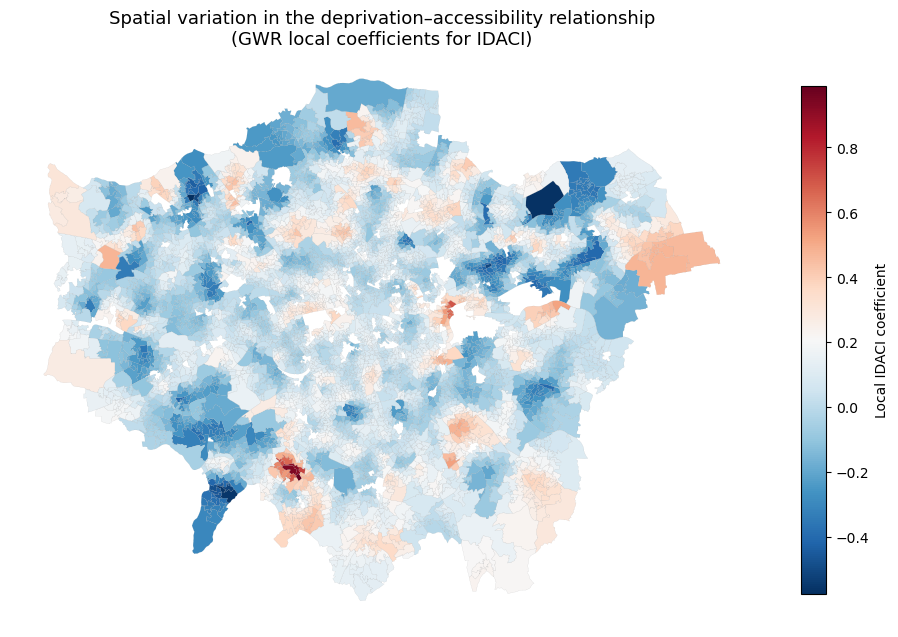

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 11))
df.plot(column="gwr_idaci_coef", cmap="RdBu_r", legend=True,
        linewidth=0.05, edgecolor="gray", ax=ax,
        legend_kwds={"label": "Local IDACI coefficient", "shrink": 0.6})
ax.set_title("Spatial variation in the deprivation–accessibility relationship\n"
             "(GWR local coefficients for IDACI)", fontsize=13)
ax.set_axis_off()
plt.savefig(f"{FIG}/gwr_coef_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
df.to_file(f"{PROC}/gwr_results.gpkg", driver="GPKG")
print("GWR results have been saved!")

GWR results have been saved!


Significant LSOAs: 804 / 4657 (17.3%)
Positively significant: 622
Negatively significant: 182


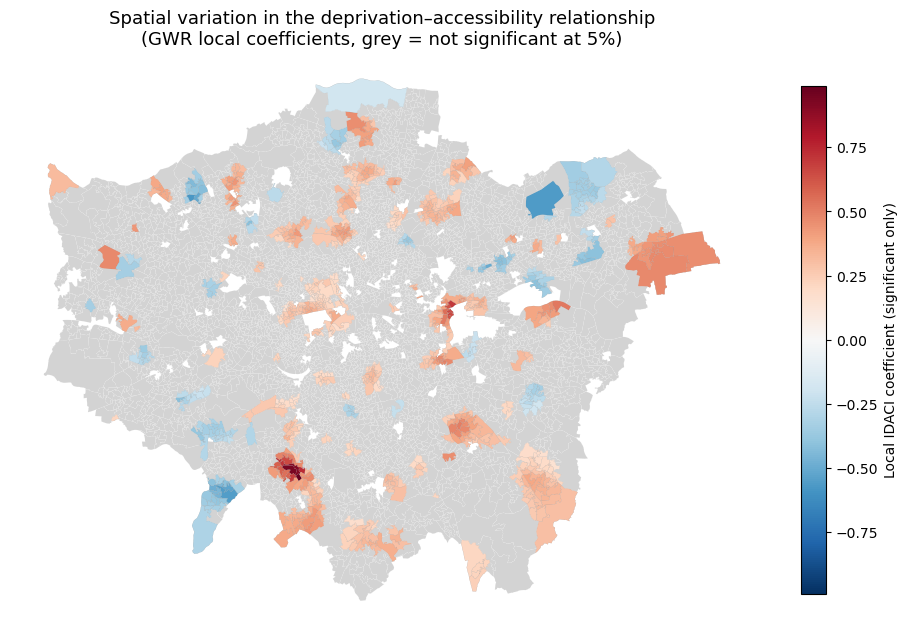

In [24]:
import numpy as np
import matplotlib.pyplot as plt

#1. Calculate local t-values.
idaci_tvals = gwr_results.tvalues[:, 1]  
df["gwr_idaci_t"] = idaci_tvals
df["sig"] = np.abs(idaci_tvals) > 1.96

n_sig = df["sig"].sum()
print(f"Significant LSOAs: {n_sig} / {len(df)} ({100*n_sig/len(df):.1f}%)")
print(f"Positively significant: {((df.gwr_idaci_coef>0) & df.sig).sum()}")
print(f"Negatively significant: {((df.gwr_idaci_coef<0) & df.sig).sum()}")

#2. Redraw: Insignificant gray marking
fig, ax = plt.subplots(figsize=(12, 11))

df.plot(ax=ax, color="lightgray", linewidth=0.05, edgecolor="white")

sig_df = df[df["sig"]]
sig_df.plot(column="gwr_idaci_coef", cmap="RdBu_r", legend=True,
            linewidth=0.05, edgecolor="gray", ax=ax,
            vmin=-df.gwr_idaci_coef.abs().max(),   # 让0居中
            vmax=df.gwr_idaci_coef.abs().max(),
            legend_kwds={"label": "Local IDACI coefficient (significant only)",
                         "shrink": 0.6})

ax.set_title("Spatial variation in the deprivation–accessibility relationship\n"
             "(GWR local coefficients, grey = not significant at 5%)", fontsize=13)
ax.set_axis_off()
plt.savefig(f"{FIG}/gwr_coef_map_sig.png", dpi=150, bbox_inches="tight")
plt.show()